In [3]:
install.packages(c("tidyverse"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



### 1. Выберите набор данных (датасет) для решения задачи классификации или регрессии.

Используем данные из Predict Diabetes https://www.kaggle.com/datasets/whenamancodes/predict-diabities?resource=download

In [6]:
library(tidyverse)

data <- read.csv("diabetes.csv")

# размер
dim(data)

[1] 768   9

In [7]:
# типы данных
str(data)


'data.frame':	768 obs. of  9 variables:
 $ Pregnancies             : int  6 1 8 1 0 5 3 10 2 8 ...
 $ Glucose                 : int  148 85 183 89 137 116 78 115 197 125 ...
 $ BloodPressure           : int  72 66 64 66 40 74 50 0 70 96 ...
 $ SkinThickness           : int  35 29 0 23 35 0 32 0 45 0 ...
 $ Insulin                 : int  0 0 0 94 168 0 88 0 543 0 ...
 $ BMI                     : num  33.6 26.6 23.3 28.1 43.1 25.6 31 35.3 30.5 0 ...
 $ DiabetesPedigreeFunction: num  0.627 0.351 0.672 0.167 2.288 ...
 $ Age                     : int  50 31 32 21 33 30 26 29 53 54 ...
 $ Outcome                 : int  1 0 1 0 1 0 1 0 1 1 ...


### 2. В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.

In [8]:
# пропуски
colSums(is.na(data))

Pregnancies                  Glucose            BloodPressure 
                       0                        0                        0 
           SkinThickness                  Insulin                      BMI 
                       0                        0                        0 
DiabetesPedigreeFunction                      Age                  Outcome 
                       0                        0                        0

In [9]:
# первые строки
head(data)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
6,5,116,74,0,0,25.6,0.201,30,0


### 3. С использованием метода train_test_split разделите выборку на обучающую и тестовую.

In [10]:
install.packages(c("caret"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



caret - Библиотека для машинного обучения. Используется для разделения данных на обучающую и тестовую выборки (createDataPartition()) и вычисления метрик качества (confusionMatrix()).

In [14]:
library(caret)

set.seed(42)

index <- createDataPartition(data$Outcome, p = 0.7, list = FALSE)

train_data <- data[index, ]
test_data  <- data[-index, ]

cat("Размер обучающей выборки:", dim(train_data))
cat("\nРазмер тестовая выборки:", dim(test_data))

Размер обучающей выборки: 538 9
Размер тестовая выборки: 230 9

### 4. Обучите следующие модели:

#### Одну из линейных моделей (линейную или полиномиальную регрессию при решении задачи регрессии, логистическую регрессию при решении задачи классификации);

Логистическая регрессия

In [22]:
log_model <- glm(Outcome ~ ., data = train_data, family = binomial)

prob_lr <- predict(log_model, test_data, type = "response")
pred_lr <- ifelse(prob_lr > 0.5, 1, 0)

pred_lr <- as.factor(pred_lr)
test_y <- test_data$Outcome

In [24]:
prob_lr <- predict(log_model, test_data, type = "response")

pred_lr <- ifelse(prob_lr > 0.5, "1", "0")
pred_lr <- factor(pred_lr, levels = c("0", "1"))

test_y <- factor(test_data$Outcome, levels = c("0", "1"))

In [26]:
conf_lr <- confusionMatrix(
    pred_lr,
    test_y,
    positive = "1"
) #позитивный 1 как в питоне

In [27]:
acc_lr <- conf_lr$overall["Accuracy"]
f1_lr <- conf_lr$byClass["F1"]

acc_lr
f1_lr

Accuracy 
0.7913043

F1 
0.6470588

SVM

In [29]:
install.packages(c("e1071"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [34]:
str(train_data)
str(test_data)

'data.frame':	538 obs. of  9 variables:
 $ Pregnancies             : int  1 8 3 10 8 4 10 1 5 7 ...
 $ Glucose                 : int  85 183 78 115 125 110 168 189 166 100 ...
 $ BloodPressure           : int  66 64 50 0 96 92 74 60 72 0 ...
 $ SkinThickness           : int  29 0 32 0 0 0 0 23 19 0 ...
 $ Insulin                 : int  0 0 88 0 0 0 0 846 175 0 ...
 $ BMI                     : num  26.6 23.3 31 35.3 0 37.6 38 30.1 25.8 30 ...
 $ DiabetesPedigreeFunction: num  0.351 0.672 0.248 0.134 0.232 0.191 0.537 0.398 0.587 0.484 ...
 $ Age                     : int  31 32 26 29 54 30 34 59 51 32 ...
 $ Outcome                 : int  0 1 1 0 1 0 1 1 1 1 ...
'data.frame':	230 obs. of  9 variables:
 $ Pregnancies             : int  6 1 0 5 2 10 1 3 1 13 ...
 $ Glucose                 : int  148 89 137 116 197 139 103 126 97 145 ...
 $ BloodPressure           : int  72 66 40 74 70 80 30 88 66 82 ...
 $ SkinThickness           : int  35 23 35 0 45 0 38 41 15 19 ...
 $ Insulin          

In [35]:
train_data$Outcome <- factor(train_data$Outcome, levels = c(0, 1))
test_data$Outcome  <- factor(test_data$Outcome, levels = c(0, 1))

In [36]:
library(e1071)

svm_model <- svm(Outcome ~ ., data = train_data, kernel = "radial")

pred_svm <- predict(svm_model, test_data)
pred_svm <- factor(pred_svm, levels = levels(test_data$Outcome))


conf_svm <- confusionMatrix(
  pred_svm,
  test_data$Outcome,
  positive = "1"
)

conf_svm$overall["Accuracy"]
conf_svm$byClass["F1"]

Accuracy 
0.773913

F1 
0.6338028

Дерево решений

In [37]:
install.packages(c("rpart"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [38]:
library(rpart)

tree_model <- rpart(Outcome ~ ., data = train_data, method = "class")

pred_tree <- predict(tree_model, test_data, type = "class")
pred_tree <- factor(pred_tree, levels = levels(test_data$Outcome))

library(caret)

conf_tree <- confusionMatrix(
  pred_tree,
  test_data$Outcome,
  positive = "1"
)

acc_tree <- conf_tree$overall["Accuracy"]
f1_tree  <- conf_tree$byClass["F1"]

acc_tree
f1_tree

Accuracy 
0.7608696

F1 
0.6099291

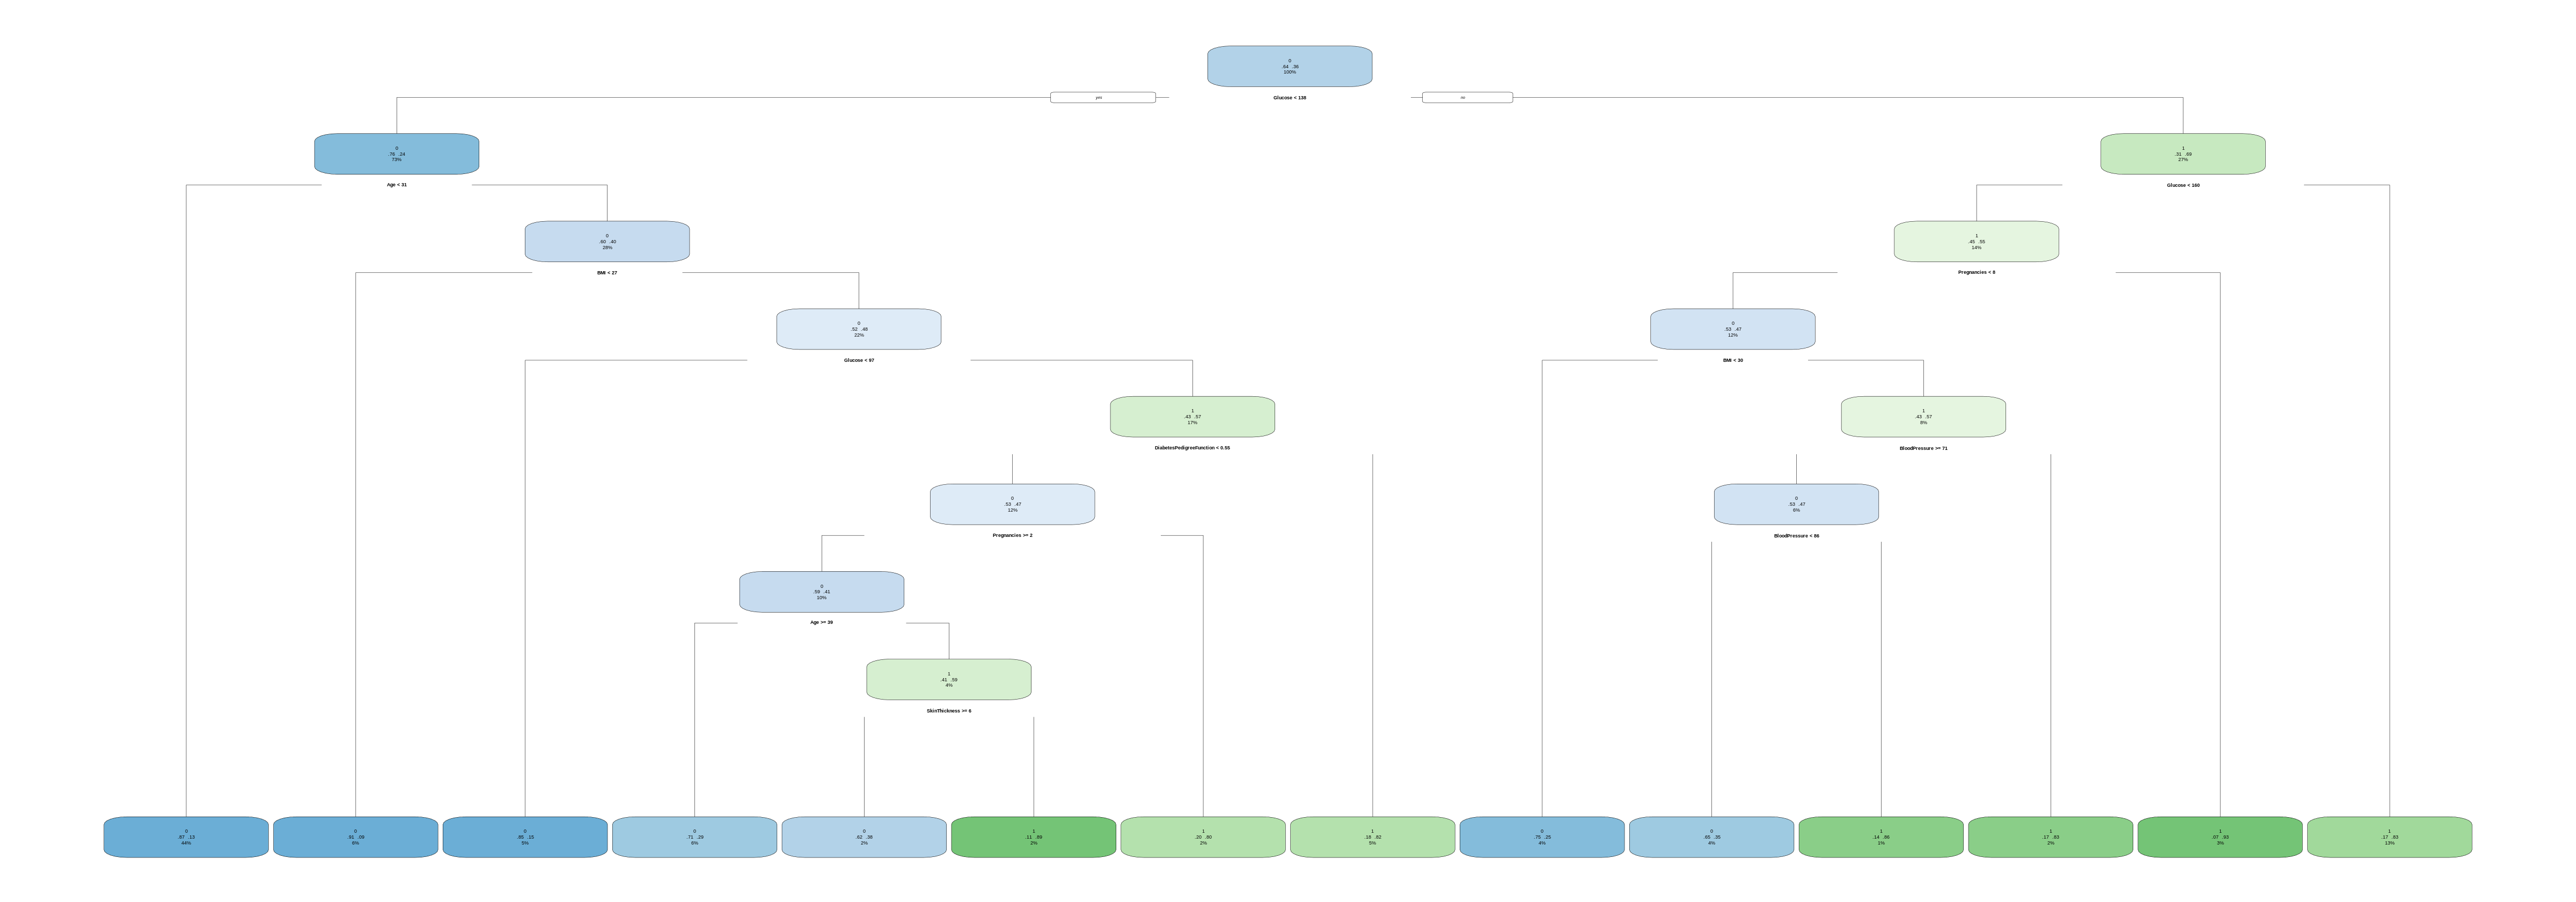

In [42]:
library(rpart.plot)
options(repr.plot.width = 40, repr.plot.height = 14)

rpart.plot(tree_model, type = 2, extra = 104, fallen.leaves = TRUE)

### 5. Оцените качество моделей с помощью двух подходящих для задачи метрик. Сравните качество полученных моделей.

In [43]:
library(caret)

# Логичистическая регрессия
conf_lr <- confusionMatrix(pred_lr, test_data$Outcome, positive = "1")
acc_lr <- conf_lr$overall["Accuracy"]
f1_lr  <- conf_lr$byClass["F1"]

# SVM
conf_svm <- confusionMatrix(pred_svm, test_data$Outcome, positive = "1")
acc_svm <- conf_svm$overall["Accuracy"]
f1_svm  <- conf_svm$byClass["F1"]

# Дерево решений
conf_tree <- confusionMatrix(pred_tree, test_data$Outcome, positive = "1")
acc_tree <- conf_tree$overall["Accuracy"]
f1_tree  <- conf_tree$byClass["F1"]

# Таблица сравнения
results <- data.frame(
  Model = c("Logistic Regression", "SVM", "Decision Tree"),
  Accuracy = c(acc_lr, acc_svm, acc_tree),
  F1_score = c(f1_lr, f1_svm, f1_tree)
)

results

Model,Accuracy,F1_score
<chr>,<dbl>,<dbl>
Logistic Regression,0.7913043,0.6470588
SVM,0.7739130,0.6338028
Decision Tree,0.7608696,0.6099291


### 6. Постройте график, показывающий важность признаков в дереве решений.

In [44]:
importance <- tree_model$variable.importance

importance_df <- data.frame(
  feature = names(importance),
  importance = as.numeric(importance)
)

importance_df <- importance_df[order(importance_df$importance), ]

importance_df

,feature,importance
,<chr>,<dbl>
8,SkinThickness,5.559190
7,BloodPressure,8.011600
6,Insulin,8.435451
5,DiabetesPedigreeFunction,8.991364
4,BMI,14.275314
3,Pregnancies,15.459779
2,Age,18.537929
1,Glucose,58.456208


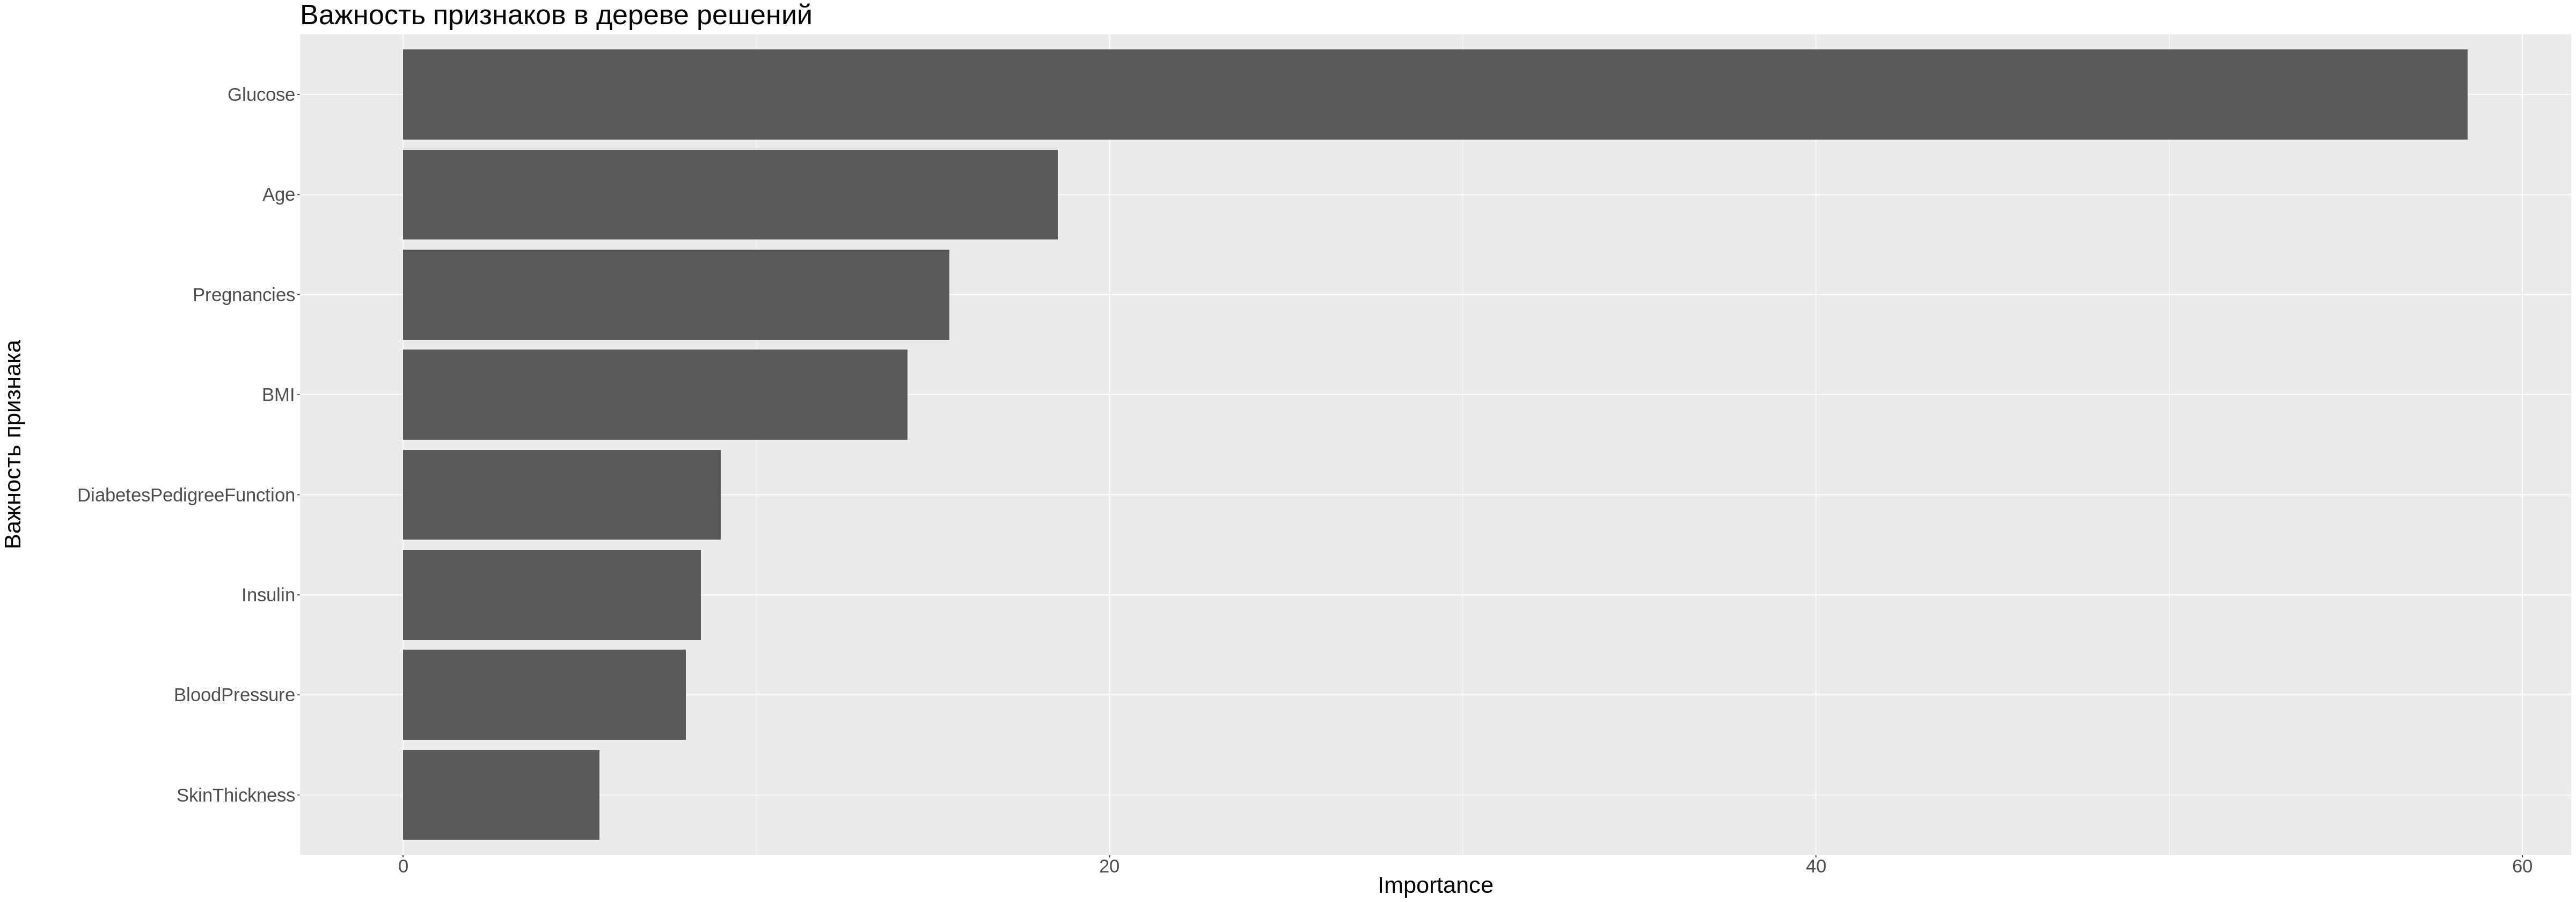

In [48]:
library(ggplot2)

ggplot(importance_df, aes(x = reorder(feature, importance), y = importance)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  xlab("Важность признака") +
  ylab("Importance") +
  ggtitle("Важность признаков в дереве решений") +
  theme(
    text = element_text(size = 26)
  )